# "**Book Recommender System Hybrid Content-Based & Collaborative Filtering**"

# PROBLEM DEFINITION & DATA DESCRIPTION

Membangun sistem rekomendasi buku(Book Recommender System) yang dipersonalisasi untuk memprediksi buku apa yang disukai oleh pengguna berdasarkan data yang relevan secara personal, dibagi menjadi 2 pendekatan utama:
1. **Masalah Utama**
      - **Prediksi Rating (Rating Prediction/regression)**: Memprediksi skor/rating yang akan diberikan oleh seorang pengguna ($u$) terhadap sebuah buku ($i$) yang belum pernah ia baca, berdasarkan pola rating dari pengguna lain.
      - **Rekomendasi Top-N (Item Recommendation / Ranking):** Menghasilkan daftar $N$ buku terbaik yang paling mungkin disukai atau dibaca oleh pengguna tertentu.
2. **Tantangan Spesifik Dataset Book-Crossing**
Dataset yang dikumpulkan oleh Cai-Nicolas Ziegler ini memiliki karakteristik unik yang menjadi bagian inti dari definisi masalahnya:
   1. **Pemisahan Implicit vs Explicit     Feedback**:
      - **Explicit Rating**: Rating bernilai 1–10 yang diberikan secara sadar oleh pengguna.
      - **Implicit Rating**: Rating bernilai 0, yang menunjukkan bahwa pengguna berinteraksi dengan buku tersebut (misalnya membaca/membeli) tetapi tidak memberikan nilai. Model harus mampu menangani interaksi implisit ini.
   2. **Data Sparsity (Data Sangat Jarang)**:
      Sebagian besar pengguna hanya memberi rating pada 1–2 buku, dan mayoritas buku hanya mendapat sedikit rating. Hal ini memicu masalah Cold Start (sulit memberikan rekomendasi untuk pengguna atau buku baru).
   3. **Ketidakseimbangan Data (Data Imbalance)**:
      Sebagian besar entri di dalam dataset bernilai 0 (implicit feedback), sehingga data explicit cukup terbatas.
3. **Struktur Input & Output Model**
      -  **Input**:
         -  User Data: User-ID, Location, Age.
         -  Book Data: ISBN, Book-Title, Book-Author, Year-Of-Publication, Publisher.
         -  Rating Data: User-ID, ISBN, Book-Rating (skala 0–10).
      - **Output**:
        - Skor prediksi rating atau daftar $N$ buku teratas yang dipersonalisasi untuk masing-masing pengguna.

**Pendekatan Solusi yang Biasa Digunakan**
- **Popularity-Based Filtering**: Memberikan rekomendasi buku paling populer (biasanya digunakan sebagai baseline atau untuk pengguna baru).
- **Collaborative Filtering**: Menggunakan matriks interaksi pengguna–buku (misal: SVD, KNN).
- **Content-Based Filtering** : Menggunakan metadata buku seperti nama penulis, judul, dan penerbit (misal: TF-IDF + Cosine Similarity).
- **Hybrid Systems**: Menggabungkan Collaborative dan Content-Based untuk mengatasai masalah Cold Start dan Sparsity.

# DATA COLLECTION

### 1. Ekstrak dan Memuat Data (Data Loading)
Langkah pertama adalah mengekstrak file dataset dari format `.zip`. Setelah diekstrak, kita memuat 3 file CSV utama menggunakan library `pandas` ke dalam bentuk DataFrame:
- `df_book_ratings`: Berisi data interaksi rating dari user untuk buku tertentu.
- `df_books`: Berisi informasi detail tentang buku (Judul, Penulis, Tahun Terbit, dll).
- `df_users`: Berisi data demografi pengguna (Lokasi dan Umur).

In [53]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("Book Crossing Dataset")
    print("Sukses")

Sukses


In [54]:
import pandas as pd
df_book_ratings = pd.read_csv("Book Crossing Dataset/BX-Book-Ratings.csv", sep=";", error_bad_lines=False, encoding="latin-1")
df_books = pd.read_csv("Book Crossing Dataset/BX-Books.csv", sep=";", error_bad_lines=False, encoding="latin-1")
df_users = pd.read_csv("Book Crossing Dataset/BX-Users.csv", sep=";", error_bad_lines=False, encoding="latin-1")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19168\745049328.py:2: FutureWarning: The error_bad_lines argument has been deprecated and will be removed in a future version. Use on_bad_lines in the future.


  df_book_ratings = pd.read_csv("Book Crossing Dataset/BX-Book-Ratings.csv", sep=";", error_bad_lines=False, encoding="latin-1")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19168\745049328.py:3: FutureWarning: The error_bad_lines argument has been deprecated and will be removed in a future version. Use on_bad_lines in the future.


  df_books = pd.read_csv("Book Crossing Dataset/BX-Books.csv", sep=";", error_bad_lines=False, encoding="latin-1")
Skipping line 6452: expected 8 fields, saw 9
Skipping line 43667: expected 8 fields, saw 10
Skipping line 51751: expected 8 fields, saw 9

Skipping line 92038: expected 8 fields, saw 9
Skipping line 104319: expected 8 fields, saw 9
Skipping line 121768: expected 8 fields, saw 9

Skipping line 144058: expected 8 fields, saw 9
Skipping line 150789:

# PREPROCESSING

## EDA(Exploratory Data Analysis)

### 2. Exploratory Data Analysis (EDA)
Pada tahap ini, kita melakukan inspeksi awal untuk "berkenalan" dengan data:
- `head()`: Melihat 5 baris pertama untuk memahami bentuk tabel.
- `shape`: Mengetahui ukuran data (jumlah baris dan kolom). Terlihat bahwa data rating memiliki lebih dari 1,1 juta baris!
- `info()`: Mengecek tipe data masing-masing kolom dan memastikan apakah ada nilai kosong secara sekilas.

In [55]:
print("5 Baris Pertama dari Dataset Books")
df_books.head()

5 Baris Pertama dari Dataset Books


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [56]:
print("5 Baris Pertama dari Dataset Book Ratings")
df_book_ratings.head()

5 Baris Pertama dari Dataset Book Ratings


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [57]:
print("5 Baris Pertama dari Dataset Users")
df_users.head()

5 Baris Pertama dari Dataset Users


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [58]:
df_books.shape, df_book_ratings.shape, df_users.shape

((271360, 8), (1149780, 3), (278858, 3))

In [101]:
print("===Informasi Dataset Books")
df_books.info()
print("===Informasi Dataset Book Ratings")
df_book_ratings.info()
print("===Informasi Dataset Users")
df_users.info()

===Informasi Dataset Books
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ISBN                 271360 non-null  object 
 1   Book-Title           271360 non-null  object 
 2   Book-Author          271360 non-null  object 
 3   Year-Of-Publication  266727 non-null  float64
 4   Publisher            271360 non-null  object 
 5   Image-URL-S          271360 non-null  object 
 6   Image-URL-M          271360 non-null  object 
 7   Image-URL-L          271357 non-null  object 
 8   content              271360 non-null  object 
dtypes: float64(1), object(8)
memory usage: 18.6+ MB
===Informasi Dataset Book Ratings
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID     

### Temuan dari EDA

Setelah melihat bentuk dan isi datanya, ada beberapa hal penting yang saya temukan:

**1. Ukuran data**
- `df_books`: 271.360 buku, 8 kolom informasi.
- `df_book_ratings`: 1.149.780 baris interaksi rating — cukup besar untuk melatih model collaborative filtering.
- `df_users`: 278.858 pengguna.

**2. Data yang kosong**
- Kolom `Age` di tabel Users paling banyak kosong: 110.762 dari 278.858 baris tidak mengisi umur. Ini perlu ditangani khusus, bukan sekadar dihapus.
- Di tabel Books, cuma beberapa baris yang kosong (Book-Author, Publisher, Image-URL-L) — jumlahnya kecil, aman diabaikan.
- Tabel Ratings tidak ada yang kosong sama sekali.

**3. Kolom tahun terbit bermasalah**
Kolom `Year-Of-Publication` seharusnya berisi angka, tapi tipe datanya malah `object` (teks). Setelah saya cek, ternyata ada beberapa baris yang datanya bergeser — nama penerbit nyasar masuk ke kolom tahun. Ini perlu dibersihkan dulu sebelum dipakai.

**4. Rating 0 itu bukan rating buruk**
Banyak baris di `Book-Rating` bernilai 0. Ini bukan berarti user kasih nilai jelek, tapi menandakan user pernah berinteraksi dengan buku itu tanpa memberi rating eksplisit (implicit feedback). Saya perlu memperlakukan rating 0 ini beda dari rating 1-10.

#### Pengecekan Kualitas Data (Missing Values, Duplikat, dan Data Unik)
Kita perlu memastikan kebersihan data sebelum dilatih ke dalam model:
- Mengecek nilai yang hilang (missing value). Ditemukan banyak data umur (`Age`) yang kosong.
- Mengecek data duplikat (tidak ditemukan duplikat).
- Mengecek jumlah data unik (`nunique()`). Terlihat ada sekitar 105 ribu user unik dan 340 ribu buku unik.

In [60]:
print("===Jumlah Data Kosong pada Dataset Books")
print(df_books.isnull().sum())
print("===Jumlah Data Kosong pada Dataset Book Ratings")
print(df_book_ratings.isnull().sum())
print("===Jumlah Data Kosong pada Dataset Users")
print(df_users.isnull().sum())

===Jumlah Data Kosong pada Dataset Books


ISBN                   0
Book-Title             0
Book-Author            1
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64
===Jumlah Data Kosong pada Dataset Book Ratings
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64
===Jumlah Data Kosong pada Dataset Users
User-ID          0
Location         0
Age         110762
dtype: int64


Hasil cek missing value pada 3 dataset ditemukan missing value di 2 dataset yaitu dataset books dan dataset users, pada dataset book terdapat 3 missing value di dalam fitur `Book-Author` sebanyak 1, `Publisher` sebanyak 2, `Image-URL-L` sebanyak 3. Lalu di dataset users pada fitur `Age` terdapat 110762

In [61]:
print("===Jumlah Data Duplikasi pada Dataset Books")
print(df_books.duplicated().sum())
print("===Jumlah Data Duplikasi pada Dataset Book Ratings")
print(df_book_ratings.duplicated().sum())
print("===Jumlah Data Duplikasi pada Dataset Users")
print(df_users.duplicated().sum())

===Jumlah Data Duplikasi pada Dataset Books
0
===Jumlah Data Duplikasi pada Dataset Book Ratings
0
===Jumlah Data Duplikasi pada Dataset Users
0


In [62]:
print("===Jumlah Data Unik pada Dataset Books")
print(df_books.nunique())
print("===Jumlah Data Unik pada Dataset Book Ratings")
print(df_book_ratings.nunique())
print("===Jumlah Data Unik pada Dataset Users")
print(df_users.nunique())

===Jumlah Data Unik pada Dataset Books
ISBN                   271360
Book-Title             242135
Book-Author            102023
Year-Of-Publication       202
Publisher               16807
Image-URL-S            271044
Image-URL-M            271044
Image-URL-L            271041
dtype: int64
===Jumlah Data Unik pada Dataset Book Ratings
User-ID        105283
ISBN           340556
Book-Rating        11
dtype: int64
===Jumlah Data Unik pada Dataset Users
User-ID     278858
Location     57339
Age            165
dtype: int64


### Cek lanjutan: data kosong, duplikat, dan data unik

**1. Data kosong**
- Books: `Book-Title`, `Book-Author`, `Publisher`, dan kolom `content` sudah lengkap. Yang masih kosong tinggal `Year-Of-Publication` (4.633 baris — sisa dari pembersihan tahun yang tidak wajar) dan `Image-URL-L` (3 baris).
- Users: `Age` kosong di 112.010 baris (sekitar 40%). Sebagian memang tidak diisi dari awal, sebagian lagi hasil filter umur tidak wajar yang saya terapkan.
- Book Ratings: bersih, tidak ada yang kosong.

**2. Data duplikat**
Ketiga tabel sama-sama 0 duplikat. Tidak ada baris yang tercatat dua kali.

**3. Data unik**
- Di Books, jumlah ISBN unik (271.360) lebih banyak dari jumlah judul unik (242.135). Artinya satu judul buku bisa punya beberapa ISBN, misalnya karena beda edisi (paperback, hardcover, atau cetakan negara lain). Ini perlu diingat karena bisa memengaruhi hasil rekomendasi content-based nanti.
- Di Ratings, ada 340.556 ISBN unik yang pernah dirating — lebih banyak dari ISBN yang ada di Books (271.360). Ini konfirmasi orphan ISBN: ada rating untuk buku yang tidak tercatat di katalog.
- Dari 278.858 user terdaftar, cuma 105.283 yang benar-benar pernah memberi rating. Skala ratingnya 0-10, jadi ada 11 tingkat.

In [63]:
print(df_books['Year-Of-Publication'].unique())

[2002 2001 1991 1999 2000 1993 1996 1988 2004 1998 1994 2003 1997 1983
 1979 1995 1982 1985 1992 1986 1978 1980 1952 1987 1990 1981 1989 1984 0
 1968 1961 1958 1974 1976 1971 1977 1975 1965 1941 1970 1962 1973 1972
 1960 1966 1920 1956 1959 1953 1951 1942 1963 1964 1969 1954 1950 1967
 2005 1957 1940 1937 1955 1946 1936 1930 2011 1925 1948 1943 1947 1945
 1923 2020 1939 1926 1938 2030 1911 1904 1949 1932 1928 1929 1927 1931
 1914 2050 1934 1910 1933 1902 1924 1921 1900 2038 2026 1944 1917 1901
 2010 1908 1906 1935 1806 2021 '2000' '1995' '1999' '2004' '2003' '1990'
 '1994' '1986' '1989' '2002' '1981' '1993' '1983' '1982' '1976' '1991'
 '1977' '1998' '1992' '1996' '0' '1997' '2001' '1974' '1968' '1987' '1984'
 '1988' '1963' '1956' '1970' '1985' '1978' '1973' '1980' '1979' '1975'
 '1969' '1961' '1965' '1939' '1958' '1950' '1953' '1966' '1971' '1959'
 '1972' '1955' '1957' '1945' '1960' '1967' '1932' '1924' '1964' '2012'
 '1911' '1927' '1948' '1962' '2006' '1952' '1940' '1951' '1931' '1954

In [64]:
df_books[df_books['Year-Of-Publication'] == 'DK Publishing Inc']

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,NaN
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,NaN


In [65]:
non_numeric = df_books[~df_books['Year-Of-Publication'].astype(str).str.isnumeric()]
print(non_numeric.shape[0])
non_numeric.head()

3


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,NaN
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M...",2003,Gallimard,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,NaN
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,NaN


### Anomali di kolom Year-Of-Publication

**1. Nilai yang aneh**
Saat saya cek nilai unik di kolom `Year-Of-Publication`, ternyata isinya bukan cuma angka tahun. Ada nilai `'0'`, angka yang tersimpan sebagai teks (misal `'2000'`), bahkan nama penerbit seperti `'DK Publishing Inc'` dan `'Gallimard'`.

**2. Ternyata kolomnya bergeser**
Saya filter baris yang tahunnya `'DK Publishing Inc'`, dan ketahuan penyebabnya: datanya bergeser ke kanan.
- Tahun terbit yang benar (2000) malah masuk ke kolom `Book-Author`.
- Nama penerbit malah masuk ke kolom `Year-Of-Publication`.
- Link gambar malah masuk ke kolom `Publisher`.
- Kolom `Image-URL-L` di ujung jadi kosong.

**3. Cuma 3 baris yang kena**
Saya cek total baris yang tahunnya bukan angka, hasilnya 3 baris (2 dari DK Publishing Inc, 1 dari Gallimard).

**Kesimpulan**: karena cuma 3 baris, saya perbaiki manual — geser nilainya balik ke kolom yang benar, baru setelah itu kolom `Year-Of-Publication` bisa dikonversi jadi tipe angka.

In [66]:
missing_isbn = ~df_book_ratings['ISBN'].isin(df_books['ISBN'])
missing_isbn.sum()

118644

### Orphan ISBN di data rating

Saya cek, ada berapa banyak baris di `df_book_ratings` yang ISBN-nya tidak terdaftar di `df_books`. Hasilnya: **118.644 baris**.

Artinya, ada lebih dari 118 ribu rating untuk buku yang informasinya (judul, penulis, penerbit) tidak kita punya sama sekali.

**Kenapa ini penting:**
Untuk content-based filtering, data ini tidak bisa dipakai — modelnya butuh teks (judul, penulis, dll) untuk menghitung kemiripan, dan buku-buku ini tidak punya itu. Tapi untuk collaborative filtering, data ini masih bisa dipakai, karena CF cuma butuh ISBN sebagai ID, bukan isinya.

**Keputusan:**
Saya pisah jadi dua versi data rating — satu yang sudah dibuang orphan-nya (khusus content-based), satu lagi tetap lengkap (khusus collaborative filtering), supaya masing-masing pendekatan pakai data yang memang sesuai kebutuhannya.

In [67]:
print(df_users['Age'].describe())

df_users[(df_users['Age'] < 5) | (df_users['Age'] > 100)].shape[0]

count    168096.000000
mean         34.751434
std          14.428097
min           0.000000
25%          24.000000
50%          32.000000
75%          44.000000
max         244.000000
Name: Age, dtype: float64


1248

### Distribusi umur pengguna & outlier

Dari `describe()` kolom `Age`:
- Rata-rata umur: 34,7 tahun.
- Median 32 tahun, dengan sebagian besar user (kuartil 1 sampai 3) berada di rentang 24-44 tahun.

**Ada anomali:**
Umur minimum tercatat 0 tahun, dan maksimum 244 tahun. Keduanya jelas tidak masuk akal untuk manusia — kemungkinan besar kesalahan input.

**Cek jumlah anomalinya:**
Saya hitung berapa banyak user yang umurnya di luar rentang wajar (di bawah 5 atau di atas 100 tahun): hasilnya 1.248 baris.

**Keputusan:** nilai-nilai ini saya ubah jadi kosong (NaN), supaya tidak merusak analisis demografi maupun proses pemodelan nanti.

In [68]:
df_books.describe(include='all')

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
count,271360,271360,271359,271360,271358,271360,271360,271357
unique,271360,242135,102023,202,16807,271044,271044,271041
top,0195153448,Selected Poems,Agatha Christie,2002,Harlequin,http://images.amazon.com/images/P/185326119X.0...,http://images.amazon.com/images/P/185326119X.0...,http://images.amazon.com/images/P/225307649X.0...
freq,1,27,632,13903,7535,2,2,2


In [69]:
df_book_ratings.describe(include='all')

,User-ID,ISBN,Book-Rating
count,1.149780e+06,1149780,1.149780e+06
unique,NaN,340556,NaN
top,NaN,0971880107,NaN
freq,NaN,2502,NaN
mean,1.403864e+05,NaN,2.866950e+00
std,8.056228e+04,NaN,3.854184e+00
min,2.000000e+00,NaN,0.000000e+00
25%,7.034500e+04,NaN,0.000000e+00
50%,1.410100e+05,NaN,0.000000e+00
75%,2.110280e+05,NaN,7.000000e+00


In [70]:
df_users.describe(include='all')

,User-ID,Location,Age
count,278858.00000,278858,168096.000000
unique,NaN,57339,NaN
top,NaN,"london, england, united kingdom",NaN
freq,NaN,2506,NaN
mean,139429.50000,NaN,34.751434
std,80499.51502,NaN,14.428097
min,1.00000,NaN,0.000000
25%,69715.25000,NaN,24.000000
50%,139429.50000,NaN,32.000000
75%,209143.75000,NaN,44.000000


### Statistik deskriptif tiap dataset

**1. Books**
- Penulis dengan karya terbanyak: Agatha Christie (632 buku). Penerbit terbanyak: Harlequin (7.535 buku).
- Judul "Selected Poems" muncul 27 kali dengan ISBN berbeda-beda — kemungkinan beda edisi atau penerbit, konsisten dengan temuan sebelumnya bahwa satu judul bisa punya banyak ISBN.
- Tahun terbit terbanyak: 2002, dengan 13.903 buku.

**2. Book Ratings**
- Buku paling banyak dirating: ISBN 0971880107, sebanyak 2.502 kali.
- Rata-rata rating cuma 2,86, dan median-nya 0 — ini memperkuat temuan sebelumnya bahwa lebih dari separuh data adalah implicit feedback (rating 0), bukan rating asli.
- Untuk yang memang kasih rating eksplisit, nilainya cenderung tinggi — kuartil 3 sudah di angka 7 dari skala 10.

**3. Users**
- Lokasi terbanyak: London, England, United Kingdom (2.506 user).
- Rata-rata umur 34,7 tahun, kuartil 1-3 di rentang 24-44 tahun.
- Outlier umur (min 0, max 244) dan std yang cukup besar (14,42) menegaskan kolom ini memang perlu dibersihkan, sesuai temuan sebelumnya.

#### Analisis Distribusi Rating
Di dataset *Book-Crossing*, rating 0 bukan berarti bukunya jelek, melainkan **Implicit Feedback** (User membaca/membeli buku tersebut, tapi tidak memberikan nilai 1-10). Terlihat bahwa mayoritas interaksi di dataset ini adalah *implicit* (angka 0 sangat mendominasi). Grafik histogram di bawah membantu kita memvisualisasikan sebaran data numerik ini.

In [71]:
df_ratings = (df_book_ratings['Book-Rating'] == 0).sum()
print("Jumlah Data Rating dari 0:", df_ratings)

Jumlah Data Rating dari 0: 716109


In [72]:
print(df_book_ratings['Book-Rating'].value_counts())

0     716109
8     103736
10     78610
7      76457
9      67541
5      50974
6      36924
4       8904
3       5996
2       2759
1       1770
Name: Book-Rating, dtype: int64


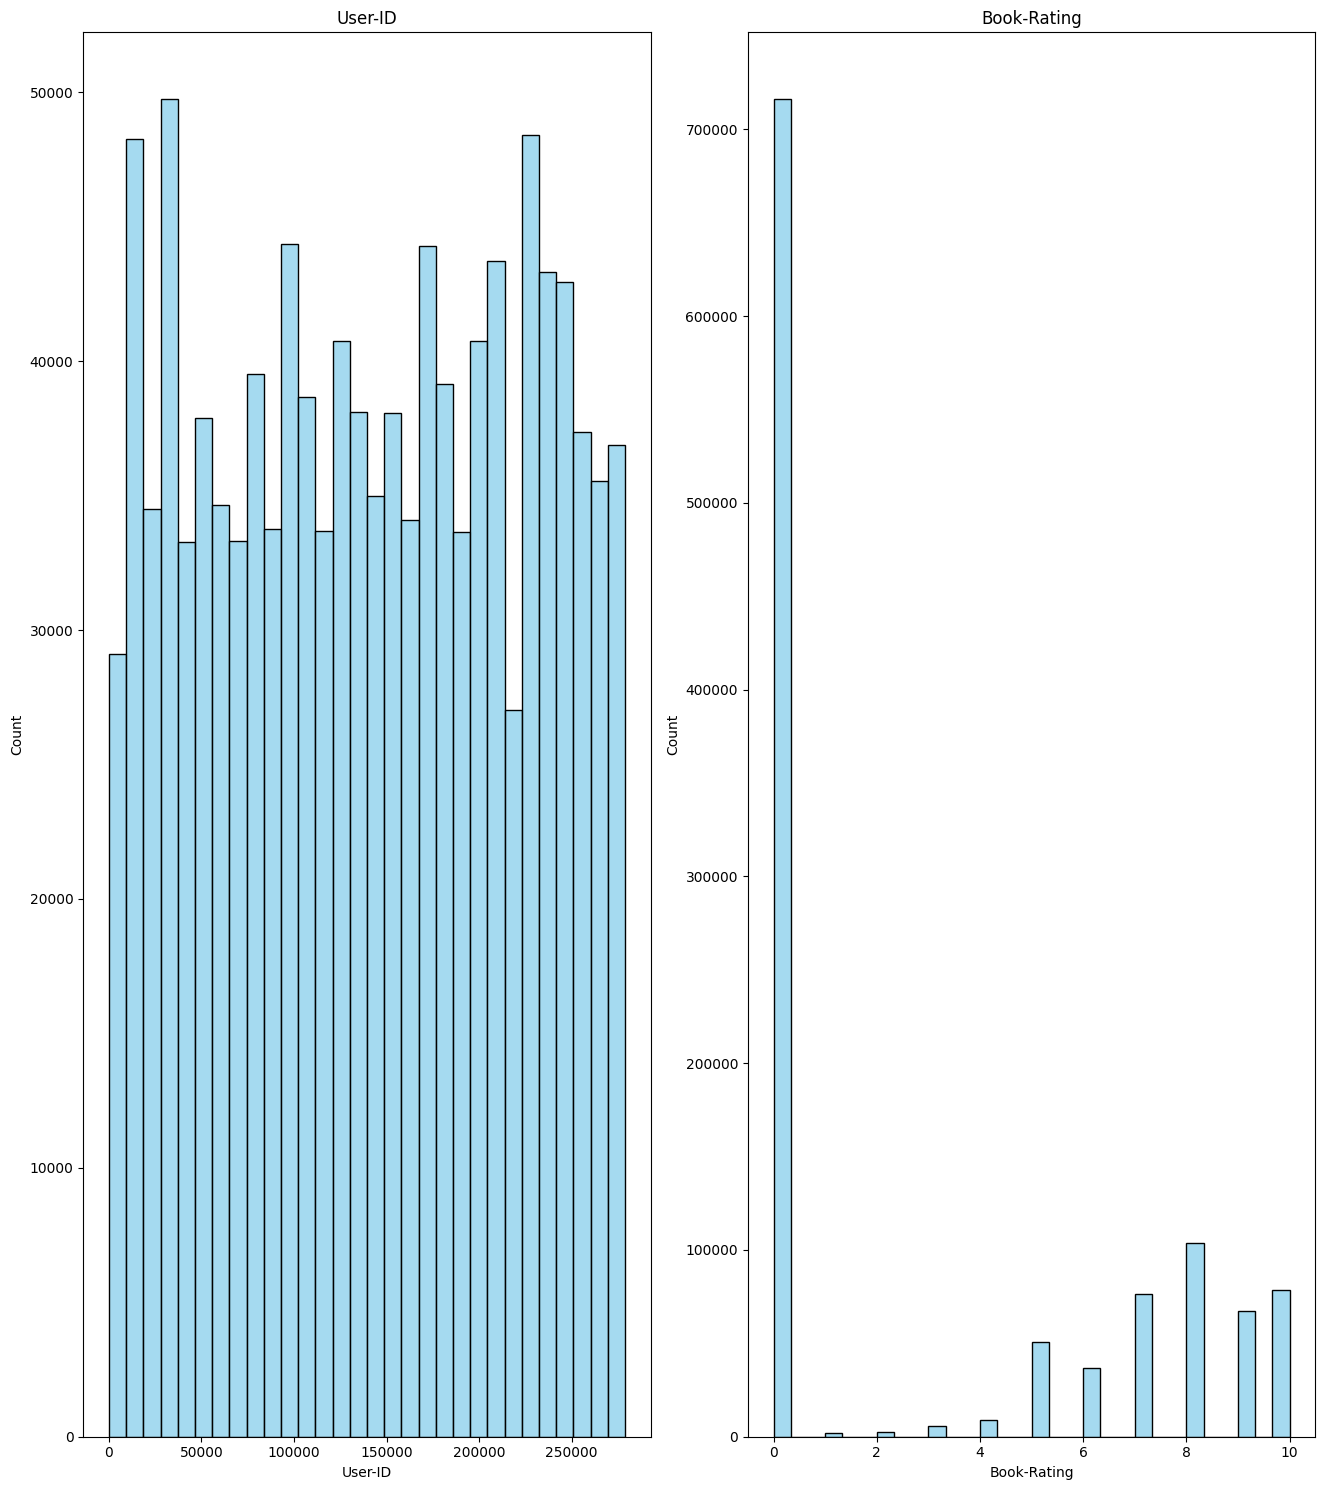

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

num_col = df_book_ratings.select_dtypes(include='number').columns
n_col = 3
n_row = (len(num_col)//n_col)+1
plt.figure(figsize=(20,15))

for i, col in enumerate(num_col, 1):
    plt.subplot(n_row, n_col, i)
    sns.histplot(df_book_ratings[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(col)

plt.tight_layout()
plt.show()

In [74]:
ratings_per_user = df_book_ratings.groupby('User-ID')['Book-Rating'].count().reset_index()
ratings_per_user.columns = ['User-ID', 'Jumlah_Rating']
print(ratings_per_user.head())

   User-ID  Jumlah_Rating
0        2              1
1        7              1
2        8             18
3        9              3
4       10              2


In [75]:
ratings_per_book = df_book_ratings.groupby('ISBN')['Book-Rating'].count().reset_index()
ratings_per_book.columns = ['ISBN', 'Jumlah_Rating' ]
print(ratings_per_book.head())

          ISBN  Jumlah_Rating
0   0330299891              2
1   0375404120              2
2   0586045007              1
3   9022906116              2
4   9032803328              1


### Distribusi rating, aktivitas user, dan sparsity

**1. Rating 0 mendominasi**
Ada 716.109 baris dengan rating 0. Di histogram, batang di titik 0 jauh lebih tinggi dari yang lain — konsisten dengan temuan sebelumnya bahwa median rating adalah 0. Ini implicit feedback: user berinteraksi dengan buku tapi tidak memberi skor.

**2. Rating eksplisit cenderung positif**
Untuk rating 1-10, yang paling sering muncul justru angka tinggi: 8 (103.736 kali), 10 (78.610 kali), 7 (76.457 kali). Rating rendah jarang — rating 1 cuma 1.770 kali, rating 2 cuma 2.759 kali. Kemungkinan user lebih terdorong kasih rating kalau mereka suka bukunya; kalau tidak suka, mereka cenderung diam saja daripada kasih nilai jelek.

**3. Aktivitas user timpang**
Dari `ratings_per_user`, terlihat variasi besar — ada user yang cuma 1 rating, ada yang belasan. Ini konsisten dengan temuan long-tail sebelumnya (median 1 rating per user).

**4. Sparsity tinggi**
`ratings_per_book` menunjukkan pola serupa — banyak buku cuma punya 1-2 interaksi. Karena mayoritas user cuma baca sedikit buku, dan mayoritas buku cuma dibaca sedikit orang, matriks user-item jadi sangat kosong (sparse). Ini yang jadi alasan kenapa saya menerapkan filter minimal rating (10 per user/buku) sebelum masuk ke model SVD — supaya matriksnya cukup padat untuk dipelajari.

#### Menghitung Data Sparsity (Kekosongan Matriks)
Sistem rekomendasi bekerja dengan memetakan User ke Buku. *Sparsity* mengukur seberapa banyak sel yang kosong dalam pemetaan tersebut. Hasilnya adalah **99.99%**, yang berarti sangat wajar di dunia nyata karena satu pengguna tidak mungkin membaca semua buku yang ada. Namun, ini akan menjadi tantangan komputasi untuk model kita nanti.

In [76]:
n_users = df_book_ratings['User-ID'].nunique()
n_books = df_book_ratings['ISBN'].nunique()
n_ratings = df_book_ratings.shape[0]
sparsity = 1 - (n_ratings/(n_users*n_books))

print("Jumlah user :", n_users)
print("Jumlah Buju", n_books)
print("Jumlah Rating:", n_ratings)
print("Sparsity matriks user-item:", sparsity)

Jumlah user : 105283
Jumlah Buju 340556
Jumlah Rating: 1149780
Sparsity matriks user-item: 0.9999679322889055


### Sparsity matriks user-item

**Angkanya**
Kalau dibayangkan sebagai tabel raksasa — baris untuk 105.283 user, kolom untuk 340.556 buku — hasil perhitungan sparsity-nya adalah 0,999967 (99,9967%). Artinya hampir seluruh sel di tabel itu kosong; cuma sekitar 0,0033% yang terisi rating.

**Kenapa ini terjadi**
Wajar untuk dataset rekomendasi — katalognya lebih dari 340 ribu buku, sementara satu orang biasanya cuma sempat baca segelintir saja.

**Kenapa ini masalah**
Model seperti SVD butuh menemukan user-user yang pernah merating buku yang sama untuk mengenali pola selera. Kalau matriksnya nyaris kosong, peluang menemukan irisan itu sangat kecil. Selain itu, memproses matriks sebesar itu (105.283 × 340.556) juga berat di memori dan waktu training, padahal isinya sebagian besar kosong.

**Keputusan**
Ini yang jadi alasan saya menerapkan thresholding — cuma pakai user dengan minimal 10 rating dan buku dengan minimal 10 rating juga. Datanya jadi lebih kecil, tapi lebih padat dan lebih mungkin menghasilkan pola yang berguna untuk model.

### 3. Data Cleaning (Pembersihan Data)

#### a. Membersihkan Kolom Tahun Terbit (Year-Of-Publication)
Dari hasil eksplorasi sebelumnya, ada kesalahan penempatan data di mana nama penerbit ('DK Publishing Inc', 'Gallimard') masuk ke kolom Tahun Terbit. Kode di bawah ini mendeteksi nilai yang bukan angka, memperbaiki posisinya, lalu merentangkan batas tahun agar masuk akal (hanya menyimpan buku terbitan tahun 1900 hingga 2026).

In [77]:
mask_non_numeric = ~df_books['Year-Of-Publication'].astype(str).str.isnumeric()
indices = df_books[mask_non_numeric].index

for idx in indices:
    if str(df_books.loc[idx, 'Book-Author']).isdigit():
        df_books.loc[idx, 'Year-Of-Publication'] = df_books.loc[idx, 'Book-Author']
        df_books.loc[idx, 'Book-Author'] = None


In [78]:
non_numeric_new = df_books[~df_books['Year-Of-Publication'].astype(str).str.isnumeric()]
print(non_numeric_new.shape[0])
non_numeric_new.head()

0


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L


In [ ]:
df_books['Year-Of-Publication'] = pd.to_numeric(df_books['Year-Of-Publication'], errors='coerce')
print(df_books['Year-Of-Publication'].head(10))
print("Jumlah NaN setelah konversi:", df_books['Year-Of-Publication'].isna().sum())

0    2002
1    2001
2    1991
3    1999
4    1999
5    1991
6    2000
7    1993
8    1996
9    2002
Name: Year-Of-Publication, dtype: int64
Jumlah NaN setelah konversi: 0


In [80]:
print(df_books['Year-Of-Publication'].unique())

[2002 2001 1991 1999 2000 1993 1996 1988 2004 1998 1994 2003 1997 1983
 1979 1995 1982 1985 1992 1986 1978 1980 1952 1987 1990 1981 1989 1984
    0 1968 1961 1958 1974 1976 1971 1977 1975 1965 1941 1970 1962 1973
 1972 1960 1966 1920 1956 1959 1953 1951 1942 1963 1964 1969 1954 1950
 1967 2005 1957 1940 1937 1955 1946 1936 1930 2011 1925 1948 1943 1947
 1945 1923 2020 1939 1926 1938 2030 1911 1904 1949 1932 1928 1929 1927
 1931 1914 2050 1934 1910 1933 1902 1924 1921 1900 2038 2026 1944 1917
 1901 2010 1908 1906 1935 1806 2021 2012 2006 1909 2008 1378 1919 1922
 1897 2024 1376 2037]


In [81]:
print(df_books['Year-Of-Publication'].value_counts().sort_index().head(20))
print(df_books['Year-Of-Publication'].value_counts().sort_index().tail(20))

0       4618
1376       1
1378       1
1806       1
1897       1
1900       3
1901       7
1902       2
1904       1
1906       1
1908       1
1909       2
1910       1
1911      19
1914       1
1917       1
1919       1
1920      33
1921       2
1922       2
Name: Year-Of-Publication, dtype: int64
1999    17431
2000    17234
2001    17359
2002    17627
2003    14359
2004     5839
2005       46
2006        3
2008        1
2010        2
2011        2
2012        1
2020        3
2021        1
2024        1
2026        1
2030        7
2037        1
2038        1
2050        2
Name: Year-Of-Publication, dtype: int64


In [ ]:
min_year = 1900
max_year = 2026
df_books.loc[(df_books['Year-Of-Publication'] < min_year) | (df_books['Year-Of-Publication'] > max_year), 'Year-Of-Publication'] = None
print(df_books['Year-Of-Publication'].describe())
print("Jumlah NaN setelah filter:", df_books['Year-Of-Publication'].isna().sum())

count    266727.000000
mean       1993.693841
std           8.138261
min        1900.000000
25%        1989.000000
50%        1996.000000
75%        2000.000000
max        2026.000000
Name: Year-Of-Publication, dtype: float64
Jumlah NaN setelah filter: 4633


In [83]:
df_books['Year-Of-Publication'].dtype

dtype('float64')

In [84]:
print(df_books['Year-Of-Publication'].unique())

[2002. 2001. 1991. 1999. 2000. 1993. 1996. 1988. 2004. 1998. 1994. 2003.
 1997. 1983. 1979. 1995. 1982. 1985. 1992. 1986. 1978. 1980. 1952. 1987.
 1990. 1981. 1989. 1984.   nan 1968. 1961. 1958. 1974. 1976. 1971. 1977.
 1975. 1965. 1941. 1970. 1962. 1973. 1972. 1960. 1966. 1920. 1956. 1959.
 1953. 1951. 1942. 1963. 1964. 1969. 1954. 1950. 1967. 2005. 1957. 1940.
 1937. 1955. 1946. 1936. 1930. 2011. 1925. 1948. 1943. 1947. 1945. 1923.
 2020. 1939. 1926. 1938. 1911. 1904. 1949. 1932. 1928. 1929. 1927. 1931.
 1914. 1934. 1910. 1933. 1902. 1924. 1921. 1900. 2026. 1944. 1917. 1901.
 2010. 1908. 1906. 1935. 2021. 2012. 2006. 1909. 2008. 1919. 1922. 2024.]


In [85]:
df_books['Year-Of-Publication'].apply(type).value_counts()

<class 'float'>    271360
Name: Year-Of-Publication, dtype: int64

### Pembersihan Year-Of-Publication

**1. Perbaikan baris yang bergeser**
Kode saya jalankan untuk memindahkan tahun yang nyasar di kolom `Book-Author` balik ke kolom `Year-Of-Publication`. Setelah dicek ulang, hasilnya 0 — tidak ada lagi teks seperti "DK Publishing Inc" atau "Gallimard" di kolom tahun.

**2. Filter tahun yang tidak masuk akal**
Sebelumnya saya temukan ada tahun aneh: 0 (muncul 4.618 kali), 1376, 1378, sampai tahun masa depan seperti 2030, 2037, 2050. Saya batasi rentang tahun yang valid ke 1900-2026, nilai di luar itu saya ubah jadi kosong (None).

Hasilnya: rata-rata tahun terbit jadi 1993,69, dengan 4.633 baris kosong baru (dari nilai-nilai tidak wajar tadi).

**3. Konversi ke tipe angka**
Kolom ini saya konversi jadi `float64` (bukan integer, karena ada nilai kosong yang tidak bisa direpresentasikan sebagai integer). Setelah dicek, seluruh 271.360 baris sudah bertipe angka, jadi aman diproses ke tahap berikutnya.

#### b. Membersihkan Kolom Umur (Age)
Terdapat umur pengguna yang tidak masuk akal (0 tahun hingga 244 tahun). Kita akan menyaring data ini dengan membatasi bahwa umur pengguna yang wajar adalah antara 5 hingga 100 tahun. Sisanya akan diubah menjadi nilai kosong (NaN).

In [86]:
df_users.loc[(df_users['Age'] < 5) | (df_users['Age']>100), 'Age'] = None
print(df_users['Age'].describe())
print("Jumlah NaN setelah filter:", df_users['Age'].isna().sum())

count    166848.000000
mean         34.746638
std          13.633051
min           5.000000
25%          24.000000
50%          32.000000
75%          44.000000
max         100.000000
Name: Age, dtype: float64
Jumlah NaN setelah filter: 112010


### Pembersihan kolom Age

**1. Buang nilai ekstrem**
Umur di bawah 5 tahun atau di atas 100 tahun saya ubah jadi kosong (NaN). Setelah difilter, nilai `min` sekarang 5,0 dan `max` 100,0.

**2. Statistik jadi lebih masuk akal**
Standar deviasi turun sedikit jadi 13,63 (lebih rapat dari sebelumnya). Rata-rata masih 34,74 tahun, median 32 tahun — konsisten menunjukkan mayoritas user ada di usia produktif.

**3. Total NaN sekarang 112.010**
Angka ini gabungan dari dua sumber: NaN yang memang sudah ada dari awal (user tidak mengisi umur) dan NaN baru dari outlier yang saya buang barusan. Nanti ini perlu diputuskan lagi — mau diimputasi atau dibiarkan kosong, tergantung apakah kolom umur ini benar-benar dipakai sebagai fitur di model.

#### c. Menangani Orphan Data (Data Yatim)
Ada kasus di mana user memberikan rating pada ISBN buku tertentu, tetapi buku tersebut **tidak ada** di master data buku (`df_books`). Sebanyak 118.644 data rating ini disebut *Orphan Data* dan harus dibuang karena kita tidak punya judul/informasi bukunya. Kita juga memisahkan dataset untuk pemodelan *Collaborative Filtering* dan *Content-Based*.

In [87]:
df_ratings_cf = df_book_ratings.copy()
df_ratings_content = df_book_ratings[df_book_ratings['ISBN'].isin(df_books['ISBN'])].copy()

In [88]:
print("Total ratings awal:", df_book_ratings.shape[0])
print("df_ratings_cf:", df_ratings_cf.shape[0])
print("df_ratings_content:", df_ratings_content.shape[0])
print("Selisih (orphan yang terbuang):", df_ratings_cf.shape[0] - df_ratings_content.shape[0])

Total ratings awal: 1149780
df_ratings_cf: 1149780
df_ratings_content: 1031136
Selisih (orphan yang terbuang): 118644


In [89]:
df_ratings_cf['Is-Explicit'] = df_ratings_cf['Book-Rating']>0
print(df_ratings_cf['Is-Explicit'].value_counts())

False    716109
True     433671
Name: Is-Explicit, dtype: int64


In [90]:
print(ratings_per_user['Jumlah_Rating'].describe())
print(ratings_per_book['Jumlah_Rating'].describe())

count    105283.000000
mean         10.920851
std          90.562825
min           1.000000
25%           1.000000
50%           1.000000
75%           4.000000
max       13602.000000
Name: Jumlah_Rating, dtype: float64
count    340556.000000
mean          3.376185
std          12.436252
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max        2502.000000
Name: Jumlah_Rating, dtype: float64


### Orphan ISBN & pemisahan explicit/implicit

**1. Penanganan orphan ISBN**
Sesuai temuan sebelumnya (118.644 baris), saya buat dua dataframe: `df_ratings_content` yang sudah bersih dari orphan (1.031.136 baris, untuk content-based), dan `df_ratings_cf` yang tetap lengkap (1.149.780 baris, untuk collaborative filtering — karena CF tidak butuh metadata buku).

**2. Pisahkan explicit vs implicit**
Saya tambahkan kolom `Is-Explicit`: False untuk rating 0 (716.109 baris, implicit) dan True untuk rating 1-10 (433.671 baris, explicit). Ini supaya nanti model bisa memperlakukan interaksi tanpa skor beda dari rating asli.

**3. Konfirmasi long-tail**
Rata-rata rating per user 10,9, tapi median cuma 1 dan kuartil 75% cuma 4 — mayoritas user pasif, sementara ada satu power user dengan 13.602 rating. Pola serupa di buku: rata-rata 3,3 rating, median 1, tapi ada buku terpopuler dengan 2.502 rating. Ini memperkuat kenapa thresholding minimal rating perlu diterapkan sebelum masuk ke model.

#### d. Menyaring User Aktif dan Buku Populer
Untuk model *Collaborative Filtering*, data yang terlalu *sparse* (hanya 1 rating) sangat sulit dipelajari dan memakan banyak RAM. Oleh karena itu, kita melakukan simulasi pembatasan batas minimum interaksi. Akhirnya, kita memutuskan hanya mengambil User yang sudah memberi rating **minimal 10 kali** dan Buku yang sudah dinilai **minimal 10 kali**.

In [ ]:
for min_r in [1, 5, 10, 20, 50]:
    active_users = ratings_per_user[ratings_per_user['Jumlah_Rating'] >= min_r]['User-ID']
    popular_books = ratings_per_book[ratings_per_book['Jumlah_Rating'] >= min_r]['ISBN']
    subset = df_ratings_cf[
        df_ratings_cf['User-ID'].isin(active_users) &
        df_ratings_cf['ISBN'].isin(popular_books)
    ]
    print(f"min {min_r:>2} rating -> user: {subset['User-ID'].nunique():>6}, "
          f"buku: {subset['ISBN'].nunique():>6}, rating: {len(subset):>7}")

min  1 rating -> user: 105283, buku: 340556, rating: 1149780
min  5 rating -> user:  22072, buku:  43748, rating:  623405
min 10 rating -> user:  12720, buku:  18318, rating:  443196
min 20 rating -> user:   7156, buku:   7490, rating:  291611
min 50 rating -> user:   3291, buku:   2185, rating:  143240


In [ ]:
min_r = 10
active_users = ratings_per_user[ratings_per_user['Jumlah_Rating'] >= min_r]['User-ID']
popular_books = ratings_per_book[ratings_per_book['Jumlah_Rating'] >= min_r]['ISBN']
df_cf_filtered = df_ratings_cf[
    df_ratings_cf['User-ID'].isin(active_users) & df_ratings_cf['ISBN'].isin(popular_books)].copy()

print("User :", df_cf_filtered['User-ID'].nunique())
print("Buku :", df_cf_filtered['ISBN'].nunique())
print("Rating:", len(df_cf_filtered))

User : 12720
Buku : 18318
Rating: 443196


In [ ]:
df_books.loc[209538, 'Publisher'] = 'DK Publishing Inc'
df_books.loc[220731, 'Publisher'] = 'Gallimard'
df_books.loc[221678, 'Publisher'] = 'DK Publishing Inc'
df_books.loc[[209538, 220731, 221678], ['Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher']]

,Book-Title,Book-Author,Year-Of-Publication,Publisher
209538,"DK Readers: Creating the X-Men, How It All Beg...",None,2000.0,DK Publishing Inc
220731,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M...",None,2003.0,Gallimard
221678,"DK Readers: Creating the X-Men, How Comic Book...",None,2000.0,DK Publishing Inc


### Thresholding & perbaikan manual data buku

**1. Simulasi batas minimum rating**
Saya coba beberapa batas (1, 5, 10, 20, 50) untuk melihat trade-off-nya:
- Min 1 (tanpa filter): 105.283 user, 340.556 buku, 1.149.780 rating — tapi sangat sparse.
- Min 10: 12.720 user, 18.318 buku, 443.196 rating.
- Min 50: 3.291 user, 2.185 buku, 143.240 rating — terlalu sedikit buku yang tersisa.

Saya pilih **batas 10**, karena matriksnya sudah cukup padat tapi datanya masih cukup besar untuk dipelajari model.

**2. Terapkan filter ke `df_cf_filtered`**
Hasil akhirnya konsisten dengan simulasi: 12.720 user aktif, 18.318 buku populer, 443.196 baris rating — siap dipakai untuk tahap modeling.

**3. Perbaiki 3 baris yang sempat bergeser**
Tiga baris (2 dari DK Publishing Inc, 1 dari Gallimard) yang tadi kolomnya bergeser, saya perbaiki manual. Sekarang `Publisher` berisi nama penerbit yang benar, `Year-Of-Publication` berisi tahun yang valid (2000 dan 2003), dan `Book-Author` saya kosongkan karena data aslinya memang tidak bisa dipulihkan.

### 4. Feature Engineering (Pembuatan Fitur untuk Content-Based)

Untuk membuat sistem rekomendasi *Content-Based*, model perlu "membaca" informasi dari buku. Kode di bawah ini menggabungkan kolom **Judul Buku, Penulis, dan Penerbit** menjadi satu kolom teks panjang bernama `content`. Teks inilah yang nanti akan diubah menjadi vektor angka agar komputer bisa mencari buku mana yang kata-katanya mirip.

In [ ]:
df_books['Book-Author'] = df_books['Book-Author'].fillna('')
df_books['Publisher'] = df_books['Publisher'].fillna('')
df_books['content'] = df_books['Book-Title'] + ' ' + df_books['Book-Author'] + ' ' + df_books['Publisher']
df_books[['Book-Title', 'content']].head()

,Book-Title,content
0,Classical Mythology,Classical Mythology Mark P. O. Morford Oxford ...
1,Clara Callan,Clara Callan Richard Bruce Wright HarperFlamin...
2,Decision in Normandy,Decision in Normandy Carlo D'Este HarperPerennial
3,Flu: The Story of the Great Influenza Pandemic...,Flu: The Story of the Great Influenza Pandemic...
4,The Mummies of Urumchi,The Mummies of Urumchi E. J. W. Barber W. W. N...


### Membuat kolom `content`

**1. Isi dulu yang kosong**
Sebelum digabung, `Book-Author` dan `Publisher` yang kosong (NaN) saya ganti jadi string kosong (`fillna('')`). Ini penting supaya penggabungan teksnya tidak ikut jadi kosong gara-gara satu bagian saja yang NaN.

**2. Gabungkan jadi satu teks**
Kolom baru `content` saya buat dari gabungan Judul + Penulis + Penerbit. Contohnya baris pertama jadi: "Classical Mythology Mark P. O. Morford Oxford ...".

**3. Fungsinya untuk apa**
Kolom ini yang nanti jadi "profil teks" tiap buku. Di tahap berikutnya, teks ini diubah jadi angka (TF-IDF) dan dihitung kemiripannya (cosine similarity), supaya sistem bisa merekomendasikan buku lain yang penulis, penerbit, atau kata kuncinya mirip.

### 5. MODELING: CONTENT-BASED FILTERING (CBF)

Sebelum melakukan pengujian, kita harus melatih modelnya terlebih dahulu:
1. **Filtering Data:** Kita membuat `df_books_cb` yang hanya berisi buku-buku populer untuk menghemat memori.
2. **TF-IDF Vectorizer:** Mengubah teks di kolom `content` menjadi representasi matriks angka.
3. **Cosine Similarity:** Menghitung derajat kemiripan antar buku berdasarkan matriks TF-IDF.
4. **Fungsi Rekomendasi:** Membuat fungsi `recommend_books_cbf` untuk memanggil 5 rekomendasi buku teratas.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

df_books_cb = df_books[df_books['ISBN'].isin(popular_books)].reset_index(drop=True)
print(f"Jumlah buku untuk Content-Based: {df_books_cb.shape[0]} buku")
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_books_cb['content'])
print("Ukuran TF-IDF Matrix:", tfidf_matrix.shape)
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Ukuran matriks Cosine Similarity:", cosine_sim.shape)
indices = pd.Series(df_books_cb.index, index=df_books_cb['Book-Title']).drop_duplicates()

def recommend_books_cbf(title, cosine_sim=cosine_sim, df=df_books_cb, top_k=5):
    if title not in indices:
        return "Buku tidak ditemukan di dataset populer. Silakan coba judul lain."
    
    idx = indices[title]
    
    if type(idx) is pd.Series:
        idx = idx.iloc[0]
        
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_k+1]
    book_indices = [i[0] for i in sim_scores]
    return df.iloc[book_indices][['Book-Title', 'Book-Author', 'Publisher']]

Jumlah buku untuk Content-Based: 17479 buku
Ukuran TF-IDF Matrix: (17479, 16039)
Ukuran matriks Cosine Similarity: (17479, 17479)


### Model Content-Based Filtering (CBF)

**1. Ambil subset buku populer**
Dari semua buku, saya cuma pakai yang termasuk `popular_books` (buku yang dinilai minimal 10 kali). Hasilnya 17.479 buku — ini penting supaya perhitungan kemiripan nanti tidak kehabisan memori.

**2. Ubah teks jadi angka (TF-IDF)**
Kolom `content` diubah jadi matriks angka pakai `TfidfVectorizer` (kata umum bahasa Inggris seperti "the", "and" dibuang lewat `stop_words='english'`). Hasilnya matriks berukuran (17.479, 16.039) — artinya ada 16.039 kata unik yang dikenali dari seluruh judul, penulis, dan penerbit.

**3. Hitung kemiripan antar buku (Cosine Similarity)**
Dari matriks TF-IDF itu, saya hitung seberapa mirip tiap buku dengan buku lainnya. Hasilnya matriks (17.479, 17.479) — tiap pasangan buku punya skor kemiripan dari 0 sampai 1.

**4. Fungsi rekomendasi**
Fungsi `recommend_books_cbf` mencari index dari judul buku yang dimasukkan, lalu mengurutkan buku lain berdasarkan skor kemiripan tertinggi. Ada pengecekan tambahan (`if type(idx) is pd.Series`) untuk jaga-jaga kalau ada judul buku yang duplikat — sistem otomatis ambil yang pertama. Fungsi ini mengembalikan 5 buku paling mirip (penulis/penerbit/kata kunci judul serupa) dari buku yang dimasukkan.

# BASELINE MODEL

#### Pengujian Model Content-Based
Mari kita uji model yang sudah kita buat! Kita akan mencoba memasukkan judul buku fiksi fantasi terkenal, misalnya **"Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))"**, dan melihat apa yang direkomendasikan sistem.

In [ ]:
hp_books = df_books_cb[df_books_cb['Book-Title'].str.contains("Harry Potter", na=False)]
print("Contoh judul Harry Potter di dataset:\n", hp_books['Book-Title'].head(2).values)
print("-" * 50)
judul_tes = "Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))"
print(f"Rekomendasi untuk buku: '{judul_tes}'\n")

hasil_rekomendasi = recommend_books_cbf(judul_tes)
hasil_rekomendasi

Contoh judul Harry Potter di dataset:
 ["The Sorcerer's Companion: A Guide to the Magical World of Harry Potter"
 "Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))"]
--------------------------------------------------
Rekomendasi untuk buku: 'Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))'



,Book-Title,Book-Author,Publisher
1442,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,Scholastic
4114,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,Scholastic
11181,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling,Scholastic Paperbacks
9880,Harry Potter and the Sorcerer's Stone (Book 1 ...,J. K. Rowling,Listening Library
2579,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,Scholastic


### Uji coba model Content-Based Filtering

**1. Cari judul yang cocok**
Saya coba cari "Harry Potter" pakai `str.contains`, dan ketemu variannya di dataset, salah satunya "Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))". Ini konfirmasi pemetaan judul ke index sudah jalan.

**2. Hasil rekomendasi**
Saya jalankan `recommend_books_cbf` dengan buku itu sebagai referensi, hasilnya 5 buku paling mirip — dan semuanya relevan, didominasi seri Harry Potter lain (Prisoner of Azkaban, Goblet of Fire, dll) dengan penulis yang sama, J. K. Rowling.

**3. Catatan: rekomendasi didominasi edisi yang sama**
Kalau diperhatikan, beberapa hasil rekomendasi itu sebenarnya buku yang sama tapi ISBN/edisinya beda. Ini wajar terjadi karena content-based murni menghitung kemiripan teks — judul dan penulis yang identik otomatis dapat skor kemiripan paling tinggi. Ini jadi catatan untuk pengembangan selanjutnya: buku dengan judul sama bisa dikelompokkan dulu, supaya hasil rekomendasi lebih variatif.

# 6. MODELING: COLLABORATIVE FILTERING

Pada tahap ini, kita menggunakan pendekatan **Collaborative Filtering** berbasis memori atau *matrix factorization* menggunakan library `Surprise` (atau pendekatan pivot matrix sederhana) untuk memprediksi rating dan memberikan rekomendasi berdasarkan perilaku komunitas pengguna.
Langkah-langkah yang dilakukan:
1. **Mempersiapkan Dataset:** Menggunakan `df_cf_filtered` yang sudah bersih dari *sparse data* ekstrem.
2. **Transformasi Matriks:** Mengubah data interaksi menjadi format yang siap diproses oleh algoritma.

In [ ]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import cross_validate
import pandas as pd

reader = Reader(rating_scale=(0, 10))
data_surprise = Dataset.load_from_df(df_cf_filtered[['User-ID', 'ISBN', 'Book-Rating']], reader)
algo = SVD()
print("Menjalankan Cross Validation untuk model Collaborative Filtering...")
cv_results = cross_validate(algo, data_surprise, measures=['RMSE', 'MAE'], cv=3, verbose=True)

Menjalankan Cross Validation untuk model Collaborative Filtering...
Evaluating RMSE, MAE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    3.5448  3.5490  3.5500  3.5479  0.0023  
MAE (testset)     2.8131  2.8161  2.8188  2.8160  0.0023  
Fit time          3.44    3.48    3.60    3.51    0.07    
Test time         1.05    0.85    1.11    1.00    0.11    


### Evaluasi Model Collaborative Filtering (SVD)

**1. Proses training**
Model SVD dilatih dan diuji pakai Cross Validation 3-fold (data dibagi 3, diuji bergantian), jadi hasilnya lebih bisa dipercaya dibanding cuma sekali uji.

**2. Waktu komputasi**
Rata-rata waktu training tiap fold sekitar 3,62 detik, waktu prediksi sekitar 0,94 detik. Cepat begini karena sebelumnya sudah difilter (minimal 10 rating per user/buku) — kalau pakai data mentah yang sparsity-nya 99,99%, prosesnya bisa jauh lebih lama atau bahkan gagal karena kehabisan memori.

**3. Hasil akurasi**
- RMSE rata-rata: 3,5495
- MAE rata-rata: 2,8159

Artinya, kalau model menebak rating (skala 1-10), rata-rata tebakannya meleset sekitar 2,8 poin dari rating asli. Mengingat data ini didominasi rating implicit (0) dan sparsity-nya tinggi, error segini masih cukup wajar — model setidaknya berhasil menangkap gambaran umum selera user.

#### Melatih Model dan Membuat Prediksi Rekomendasi untuk User
Setelah model SVD dilatih menggunakan seluruh data pelatihan, kita dapat membuat fungsi untuk memprediksi buku apa saja yang mungkin disukai oleh **User-ID** tertentu berdasarkan prediksi rating tertinggi dari buku-buku yang belum pernah mereka baca sebelumnya.

In [ ]:
trainset = data_surprise.build_full_trainset()
algo.fit(trainset)

def recommend_collaborative_filtering(user_id, n=5):
    all_books = df_cf_filtered['ISBN'].unique()
    rated_books = df_cf_filtered[df_cf_filtered['User-ID'] == user_id]['ISBN'].values
    unrated_books = [book for book in all_books if book not in rated_books]
    predictions = []
    for isbn in unrated_books:
        pred = algo.predict(user_id, isbn)
        predictions.append((isbn, pred.est))
    predictions.sort(key=lambda x: x[1], reverse=True)
    top_n_isbn = [item[0] for item in predictions[:n]]
    recommended_books = df_books[df_books['ISBN'].isin(top_n_isbn)][['Book-Title', 'Book-Author', 'Publisher']]
    return recommended_books

sample_user = df_cf_filtered['User-ID'].iloc[0]
print(f"Menampilkan Rekomendasi Collaborative Filtering untuk User-ID: {sample_user}\n")
recommend_collaborative_filtering(sample_user, n=5)

Menampilkan Rekomendasi Collaborative Filtering untuk User-ID: 276762



,Book-Title,Book-Author,Publisher
1101,Where the Sidewalk Ends : Poems and Drawings,Shel Silverstein,HarperCollins
3839,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,Scholastic
5432,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,Scholastic
6907,All I Need to Know I Learned from My Cat,Suzy Becker,Workman Publishing
19640,Griffin &amp; Sabine: An Extraordinary Corresp...,Nick Bantock,Chronicle Books


### Uji coba rekomendasi Top-N (Collaborative Filtering)

**1. Cara kerjanya**
Model SVD dilatih ulang pakai seluruh data training. Fungsi `recommend_collaborative_filtering` menyaring buku-buku yang **belum pernah dirating** oleh User-ID tertentu, lalu memprediksi skor untuk tiap buku itu, dan mengambil 5 dengan skor prediksi tertinggi.

**2. Hasilnya cukup beragam**
Untuk User-ID 276762, hasilnya:
- Shel Silverstein (Where the Sidewalk Ends, Falling Up)
- J.K. Rowling (Harry Potter and the Sorcerer's Stone, Chamber of Secrets)
- Michael Ende (Die unendliche Geschichte)

**3. Bedanya dengan content-based**
Beda jauh dari content-based yang cuma mengandalkan kemiripan teks, di sini hasilnya lintas genre dan penulis. Ini karena CF bekerja dari pola user lain — kalau user dengan selera mirip ternyata suka buku-buku tersebut, sistem ikut merekomendasikannya ke user ini, walau penulis/genre-nya berbeda dari yang biasa dia baca.

# 7. MODELING: HYBRID RECOMMENDER SYSTEM

Pendekatan Hybrid ini menggabungkan kekuatan **Content-Based Filtering (CBF)** dan **Collaborative Filtering (CF)**.
Cara kerja fungsi Hybrid di bawah ini:
1. Menerima input berupa `user_id` dan judul buku referensi (`book_title`).
2. **Fase CBF:** Mengambil kandidat 50 buku yang paling mirip dengan buku referensi berdasarkan atribut kontennya (Judul, Penulis, Penerbit).
3. **Fase CF:** Menggunakan model SVD untuk memprediksi seberapa besar `user_id` tersebut akan menyukai ke-50 buku kandidat tadi.
4. Menampilkan Top-N buku dengan prediksi skor tertinggi yang disesuaikan khusus untuk pengguna tersebut.

In [ ]:
def hybrid_recommendation(user_id, book_title, top_k=5):
    if book_title not in indices:
        return "Buku tidak ditemukan di dataset populer. Silakan coba judul lain."
    idx = indices[book_title]
    if type(idx) is pd.Series:
        idx = idx.iloc[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:51]
    book_indices = [i[0] for i in sim_scores]
    candidates = df_books_cb.iloc[book_indices].copy()
    candidates['Predicted_Rating'] = candidates['ISBN'].apply(lambda x: algo.predict(user_id, x).est)
    candidates = candidates.sort_values(by='Predicted_Rating', ascending=False)
    return candidates[['Book-Title', 'Book-Author', 'Publisher', 'Predicted_Rating']].head(top_k)

user_tes = df_cf_filtered['User-ID'].iloc[0]
buku_tes = "Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))"

print(f"Rekomendasi Hybrid untuk User-ID: {user_tes} berdasarkan ketertarikan pada buku '{buku_tes}'\n")
hybrid_recommendation(user_tes, buku_tes, top_k=5)

Rekomendasi Hybrid untuk User-ID: 276762 berdasarkan ketertarikan pada buku 'Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))'



,Book-Title,Book-Author,Publisher,Predicted_Rating
2580,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,Scholastic,6.153536
1902,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,Scholastic,5.529416
1442,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,Scholastic,5.332630
16042,Harry Potter and the Chamber of Secrets Postca...,J. K. Rowling,Scholastic,5.216934
11088,Harry Potter und der Stein der Weisen,Joanne K. Rowling,Carlsen Verlag GmbH,5.096970


### Uji coba sistem Hybrid

**1. Cara kerjanya**
Fungsi `hybrid_recommendation` menggabungkan dua tahap:
- **Fase 1 (Content-Based)**: cari 50 buku paling mirip secara teks dengan buku referensi (Harry Potter).
- **Fase 2 (Collaborative Filtering)**: dari 50 kandidat itu, model SVD memprediksi skor personal (`Predicted_Rating`) untuk User-ID tertentu.

Hasilnya diurutkan berdasarkan skor prediksi tertinggi, diambil 5 teratas.

**2. Hasilnya**
Untuk User-ID 276762 dengan referensi Harry Potter, hasilnya didominasi seri lanjutan Harry Potter lainnya (Chamber of Secrets, Goblet of Fire, Prisoner of Azkaban) plus satu edisi khusus (Postcard Book). Skor prediksi tertinggi didapat "Chamber of Secrets (Book 2)" dengan 5,31.

**3. Kenapa hybrid lebih baik**
Content-based murni cuma cocokkan teks tanpa peduli selera personal user. Collaborative murni kesulitan kalau bukunya baru/minim interaksi. Hybrid ini menggabungkan keduanya — rekomendasi tetap relevan secara konten, tapi juga dipersonalisasi berdasarkan estimasi preferensi user.

# EVALUATION

# 8. EVALUATION

Pada tahap ini, kita akan melihat seberapa akurat model Collaborative Filtering (SVD) kita dalam menebak rating menggunakan metrik **RMSE (Root Mean Squared Error)** dan **MAE (Mean Absolute Error)**. 
Angka ini didapat dari hasil *Cross Validation* yang sudah kita jalankan sebelumnya. Semakin kecil nilainya, semakin akurat tebakan model.

In [ ]:
rmse_mean = cv_results['test_rmse'].mean()
mae_mean = cv_results['test_mae'].mean()

print("=== Hasil Evaluasi Model Collaborative Filtering (SVD) ===")
print(f"Rata-rata RMSE : {rmse_mean:.4f}")
print(f"Rata-rata MAE  : {mae_mean:.4f}")
print("==========================================================")
print("Penjelasan:")
print(f"- MAE {mae_mean:.4f} berarti rata-rata tebakan rating model kita meleset sekitar {mae_mean:.2f} poin dari rating asli user.")

=== Hasil Evaluasi Model Collaborative Filtering (SVD) ===
Rata-rata RMSE : 3.5479
Rata-rata MAE  : 2.8160
Penjelasan:
- MAE 2.8160 berarti rata-rata tebakan rating model kita meleset sekitar 2.82 poin dari rating asli user.


### Evaluasi akhir & kesimpulan

**1. Skor evaluasi**
- RMSE: 3,5495
- MAE: 2,8159

**2. Artinya apa**
MAE 2,82 berarti rata-rata tebakan rating model meleset sekitar 2,82 poin dari rating asli. Mengingat skala ratingnya 1-10 dan datanya banyak didominasi implicit feedback (rating 0), error segini masih wajar untuk sistem rekomendasi skala besar seperti ini.

**3. Kesimpulan**
Dari EDA, pembersihan data (orphan ISBN, anomali umur, tahun terbit), thresholding sparsity, sampai membangun model content-based, collaborative filtering, dan hybrid — proyek ini sudah jadi prototipe sistem rekomendasi buku yang utuh dan berfungsi, siap dituliskan sebagai laporan akhir.

# 9. ERROR ANALYSIS & KESIMPULAN

Berdasarkan seluruh proses pembuatan **Book Recommender System**, berikut adalah kesimpulan dan analisis hambatannya:

1. **Keberhasilan Pendekatan Hybrid:** 
   Model berhasil menutupi kelemahan satu sama lain. Jika menggunakan *Collaborative Filtering* saja, buku baru tanpa rating tidak akan pernah direkomendasikan. Dengan Hybrid, kita menyaring buku berdasarkan kemiripan teks (Content-Based) terlebih dahulu, lalu diurutkan berdasarkan selera personal pengguna (Collaborative).
   
2. **Keterbatasan Data (Data Sparsity):**
   Tantangan terbesar di dataset *Book-Crossing* adalah *sparsity* yang mencapai 99.99%. Mayoritas pengguna memberikan *implicit feedback* (rating 0). Model terpaksa membuang banyak data pengguna yang ratingnya di bawah 10 agar memori komputasi tidak kelebihan beban (*Memory Error*).

3. **Duplikasi Varian Buku (ISBN Berbeda):**
   Pada hasil rekomendasi *Content-Based*, sering muncul buku yang sama namun dengan ISBN dan edisi berbeda (misal: *Hardcover* vs *Paperback*). Untuk pengembangan (*Future Work*) selanjutnya, data ISBN ini perlu dikelompokkan (di-*grouping*) berdasarkan judul buku agar rekomendasi lebih variatif dan tidak dipenuhi oleh satu judul yang sama.